### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
from tqdm import tqdm_notebook
import math
import h5py

In [71]:
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu

In [4]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical, plot_model

In [5]:
import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras import Model, layers, optimizers, utils, callbacks

### Step 2: Load Data

In [6]:
images_dir = './data/flickr8k/images/'
captions_path = './data/flickr8k/captions.txt'

In [7]:
captions = pd.read_csv(captions_path)

In [8]:
captions['caption'] = captions['caption'].str.lower()

In [9]:
captions.shape

(40455, 2)

In [10]:
captions.head()

,image,caption
0,1000268201_693b08cb0e.jpg,a child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,a girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,a little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,a little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,a little girl in a pink dress going into a woo...


### Step 3: Cleaning The Captions

In [11]:
captions['caption']= (
    captions['caption']
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\d+", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [12]:
captions['caption'] = 'start ' + captions['caption'] + ' end'

### Step 4: Load Images with Captions

In [13]:
temp = captions.groupby('image')['caption'].apply(lambda x: '\n\n'.join(x))

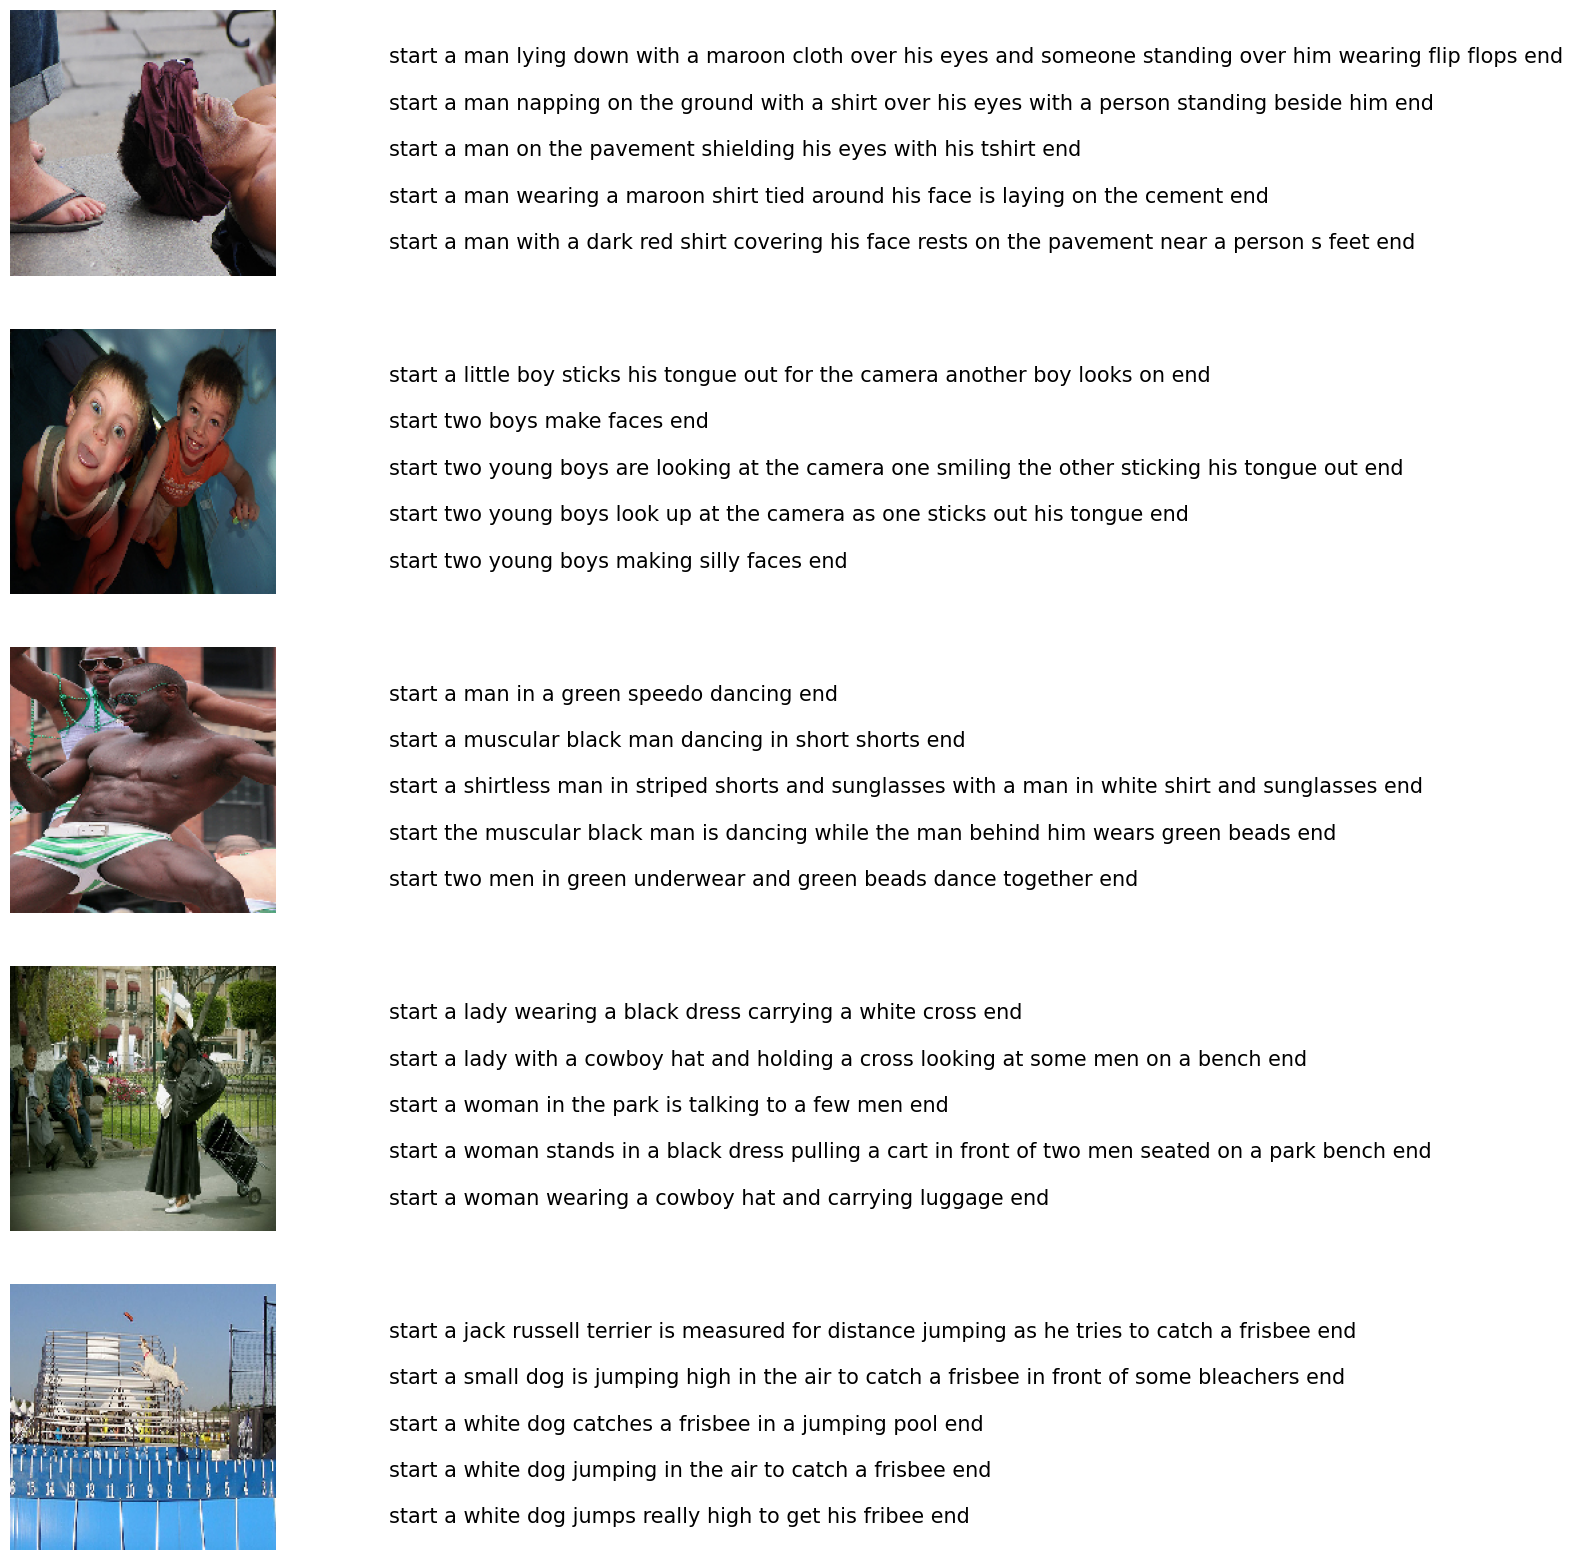

In [14]:
plt.figure(figsize=(10, 20))
for i in range(5):
    idx = random.randint(0, len(temp)-1)
    plt.subplot(5, 2, 2*i+1)
    img = load_img(images_dir + temp.index[idx], target_size=(199, 199, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.subplot(5, 2, 2*i+2)
    plt.axis('off')
    plt.text(0, 0.1, temp[idx], fontsize=15)

### Step 5: Exploring the Caption Length Distribution

In [15]:
temp = captions['caption'].str.split().apply(len)

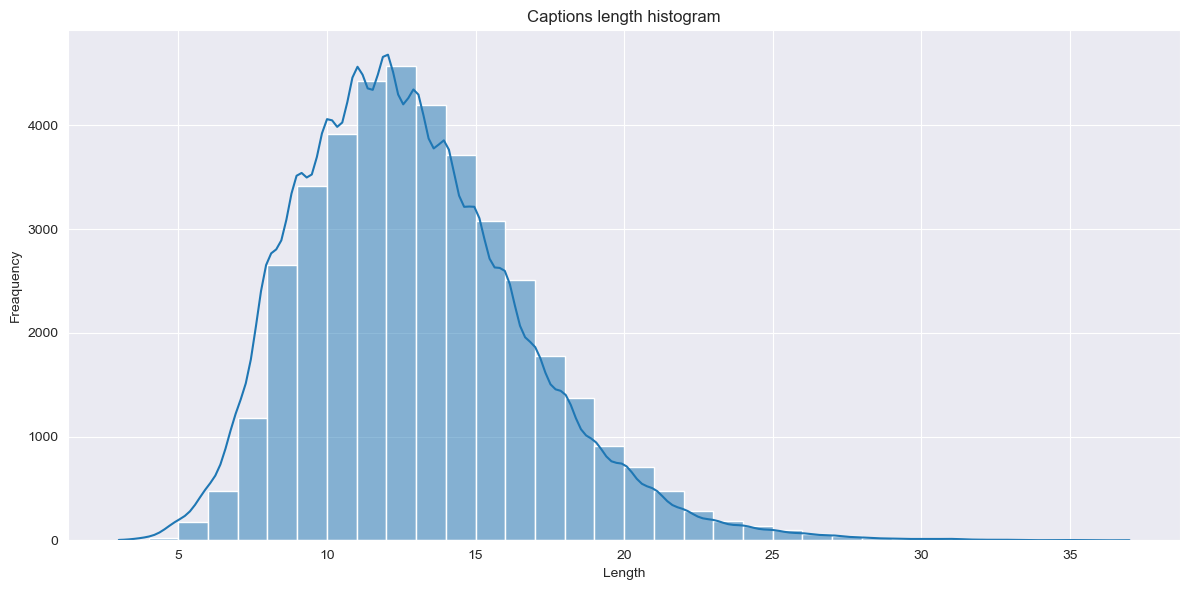

In [16]:
plt.figure(figsize=(12, 6))
sns.set_style('darkgrid')
sns.histplot(x=temp, kde=True, binwidth=1)
plt.title('Captions length histogram')
plt.xlabel('Length')
plt.ylabel('Freaquency')
plt.tight_layout()

### Step 6: Tokenizing Vocabulary

In [17]:
tokenizer = Tokenizer()

In [18]:
tokenizer.fit_on_texts(captions['caption'])

In [19]:
vocab_size = len(tokenizer.word_index) + 1

### Step 7: Splitting Data

In [20]:
train, test = train_test_split(
    captions,
    test_size=0.4,
    random_state=42
)

In [21]:
value, test = train_test_split(
    test,
    test_size=0.5,
    random_state=42
)

### Step 8: Extract Image Feature

In [22]:
inception = InceptionV3(weights='imagenet', input_shape=(299, 299, 3), include_top=True)

In [23]:
inception = Model(inputs=inception.input, outputs=inception.layers[-2].output)

In [24]:
image_features = dict()

In [25]:
image_ids = captions['image'].unique()

In [26]:
pbar = tqdm_notebook(total=len(image_ids), position=0, leave=True, colour='green')
for image_id in image_ids:
    image_path = os.path.join(images_dir, image_id)
    img = load_img(image_path, target_size=(299, 299, 3))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    img = inception.predict(img, verbose=0)
    image_features[image_id] = img.flatten()
    pbar.update(1)

  0%|          | 0/8091 [00:00<?, ?it/s]

In [29]:
with h5py.File('./data/image_caption_features.h5', 'w') as f:
    for image_id, feature in image_features.items():
        # 将每个特征存储到 HDF5 文件中，image_id 作为 key
        f.create_dataset(image_id, data=feature)

In [31]:
with h5py.File('./data/image_caption_features.h5', 'r') as f:
    for image_id, feature in f.items():
        image_features[image_id] = feature[:]

In [50]:
def data_generator(captions, image_features, tokenizer, max_caption_length, batch_size):
    num_samples = len(captions)
    image_ids = list(image_features.keys())
    while True:
        np.random.shuffle(image_ids)  # Shuffle image_ids for each epoch
        for start_idx in range(0, num_samples, batch_size):
            end_idx = min(start_idx + batch_size, num_samples)
            X_images, X_captions, y = [], [], []
            for _, caption in captions.iloc[start_idx:end_idx].iterrows():
                image_id, caption_text = caption['image'], caption['caption']
                # caption_text = caption_text.rstrip('\n')
                seq = tokenizer.texts_to_sequences([caption_text])[0] # Tokenizing the caption
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i] # X_caption, Y
                    in_seq = pad_sequences([in_seq], maxlen=max_caption_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    X_images.append(image_features[image_id])
                    X_captions.append(in_seq)
                    y.append(out_seq)
            yield (np.array(X_images), np.array(X_captions)), np.array(y)

In [51]:
max_caption_length = captions['caption'].str.split().apply(len).max() + 1

In [52]:
cnn_output_dim = inception.output_shape[1]

In [53]:
batch_size_train = 270
batch_size_value = 150

In [54]:
train_data_generator = data_generator(train, image_features, tokenizer, max_caption_length, batch_size_train)
value_data_generator = data_generator(value, image_features, tokenizer, max_caption_length, batch_size_value)

### Step 9: Building Model

In [55]:
input_image = layers.Input(shape=(cnn_output_dim,), name='Features_Input')
input_caption = layers.Input(shape=(max_caption_length,), name='Sequence_Input')

In [56]:
x_image = layers.BatchNormalization()(input_image)
x_image = layers.Dense(256, activation='relu')(x_image)
x_image = layers.BatchNormalization()(x_image)

In [57]:
x_caption = layers.Embedding(vocab_size, 256, mask_zero=True)(input_caption)
x_caption = layers.LSTM(256)(x_caption)

In [58]:
decoder = layers.add([x_image, x_caption])
decoder = layers.Dense(256, activation='relu')(decoder)
outputs = layers.Dense(vocab_size, activation='softmax', name='Output_Layer')(decoder)

In [59]:
model = Model(inputs=[input_image, input_caption], outputs=outputs, name='Image_Captioning')

In [60]:
model.summary()

Model: "Image_Captioning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Features_Input (InputLayer)   │ (None, 2048)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_94        │ (None, 2048)              │           8,192 │ Features_Input[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Sequence_Input (InputLayer)   │ (None, 38)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 256)               │         524,544 │ batch_normalization_94[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 38, 256)           │       2,247,424 │ Sequence_Input[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, 38)                │               0 │ Sequence_Input[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_95        │ (None, 256)               │           1,024 │ dense[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 256)               │         525,312 │ embedding[0][0],           │
│                               │                           │                 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 256)               │               0 │ batch_normalization_95[0]… │
│                               │                           │                 │ lstm[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 256)               │          65,792 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Output_Layer (Dense)          │ (None, 8779)              │       2,256,203 │ dense_1[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 5,628,491 (21.47 MB)

 Trainable params: 5,623,883 (21.45 MB)

 Non-trainable params: 4,608 (18.00 KB)

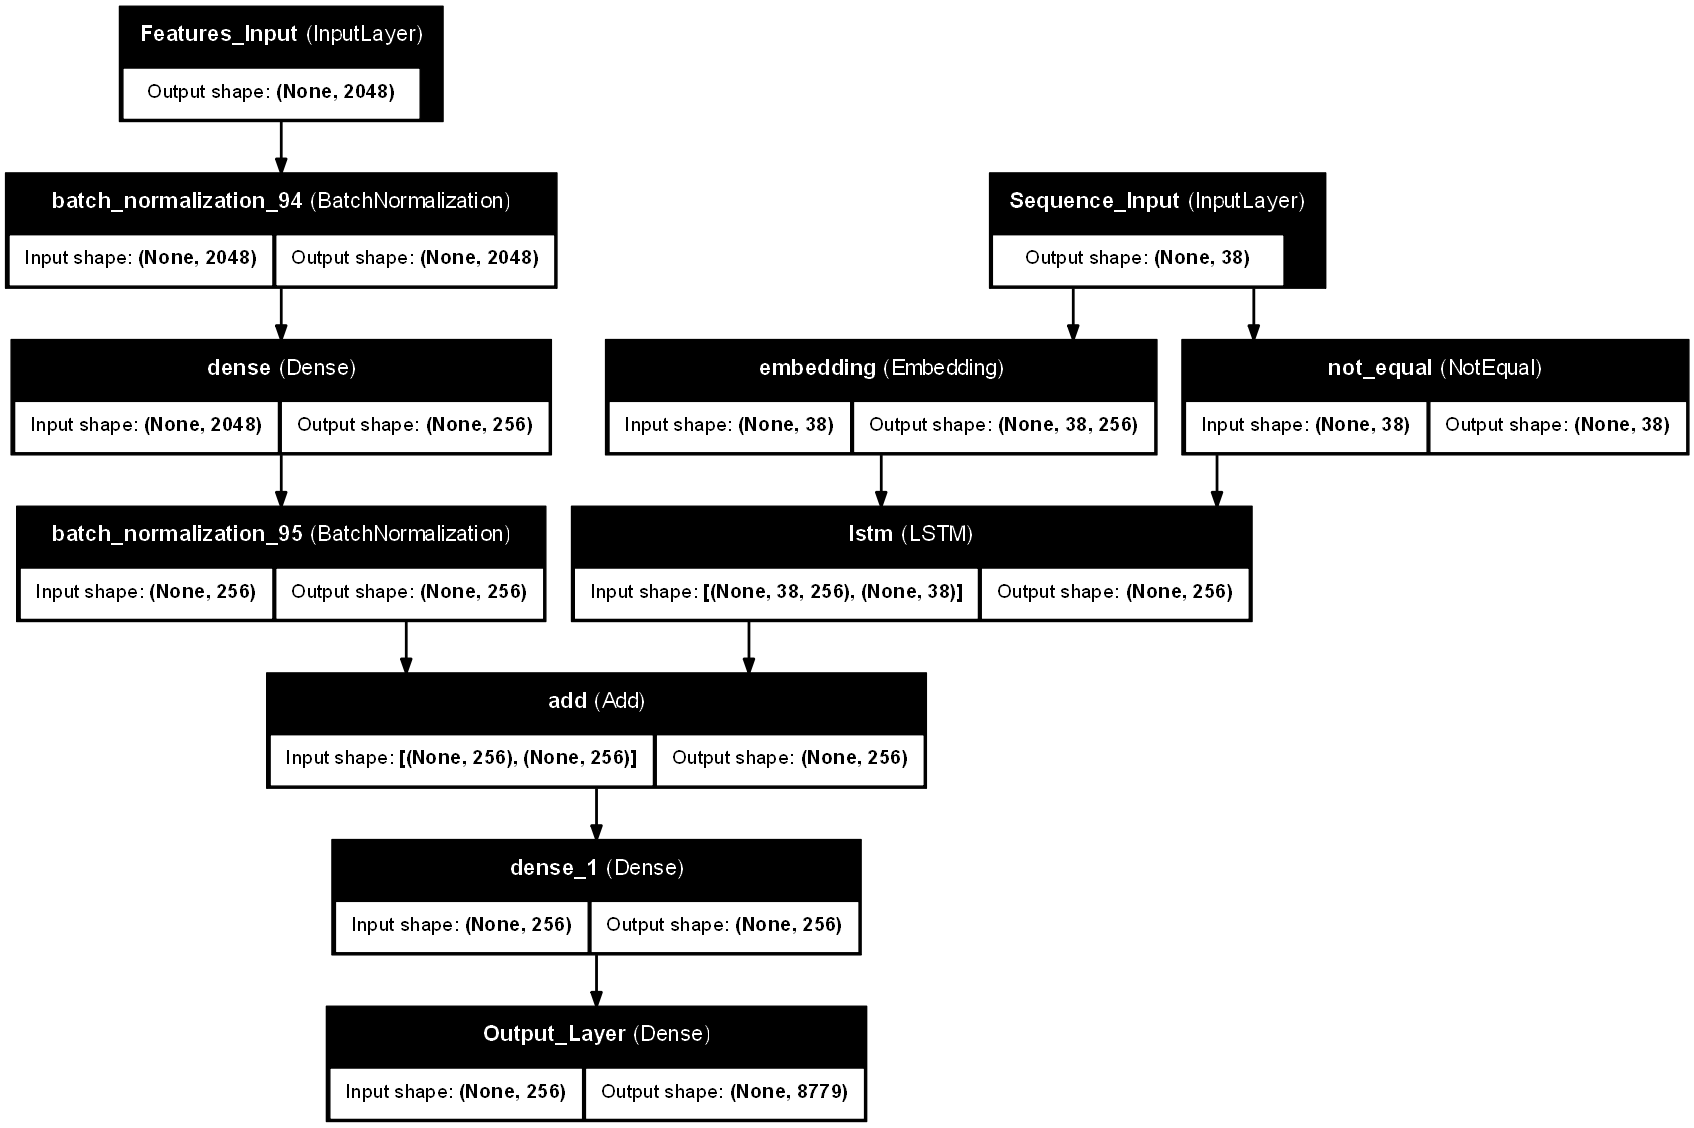

In [61]:
plot_model(model,show_layer_names=True, show_shapes=True, dpi=100)

In [62]:
optimizer = optimizers.Adam(learning_rate=0.01, clipnorm=1.0)

In [63]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
)

### Step 10 Training Model

In [64]:
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [65]:
def lr_scheduler(epoch, lr):
    return lr * math.exp(-0.6)
lr_schedule = callbacks.LearningRateScheduler(lr_scheduler)

In [66]:
train_steps = len(train) // batch_size_train
value_steps = len(value) // batch_size_value

In [67]:
history = model.fit(
    train_data_generator,
    steps_per_epoch=train_steps,
    validation_data=value_data_generator,
    validation_steps=value_steps,
    epochs=15,
    callbacks=[early_stopping, lr_schedule]
)

Epoch 1/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - loss: 4.4605 - val_loss: 3.7776 - learning_rate: 0.0055
Epoch 2/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - loss: 3.1885 - val_loss: 3.3327 - learning_rate: 0.0030
Epoch 3/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 241s 3s/step - loss: 2.7793 - val_loss: 3.1705 - learning_rate: 0.0017
Epoch 4/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 245s 3s/step - loss: 2.5418 - val_loss: 3.1133 - learning_rate: 9.0718e-04
Epoch 5/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 246s 3s/step - loss: 2.3936 - val_loss: 3.0964 - learning_rate: 4.9787e-04
Epoch 6/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 240s 3s/step - loss: 2.3037 - val_loss: 3.0971 - learning_rate: 2.7324e-04
Epoch 7/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 239s 3s/step - loss: 2.2504 - val_loss: 3.0988 - learning_rate: 1.4996e-04
Epoch 8/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - loss: 2.2219 - val_loss: 3.1058 - learning_rate: 8.2297e-05
Epoch 9/15
89/89 ━━━━━━━━━━━━━━━━━━━━ 244s 3s/step - loss: 2.2047 - val_loss: 3.1059 - learning_rate: 4.5166

In [85]:
model.save('./data/image_caption_model.keras')

In [86]:
load_model = tf.keras.models.load_model('./data/image_caption_model.keras')

### Step 11: Visualizing Loss

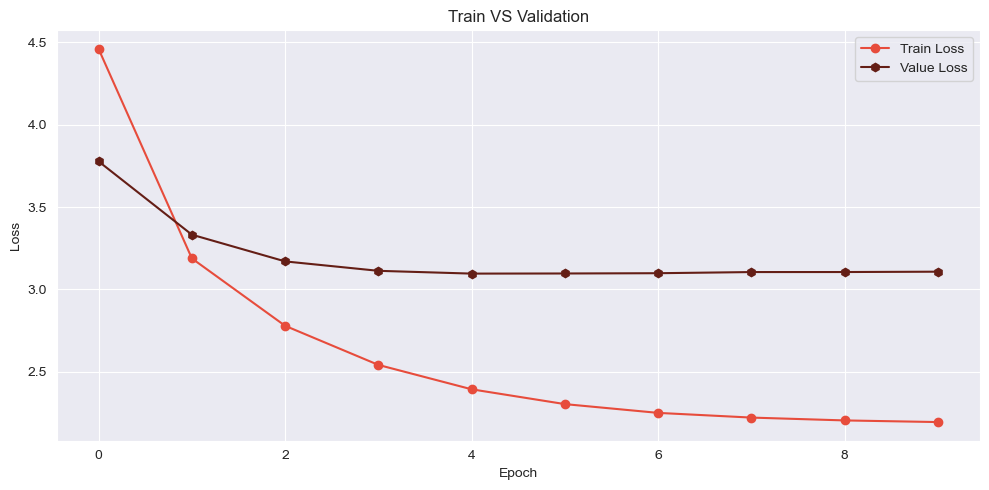

In [68]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss', color='#E74C3C', marker='o')
plt.plot(history.history['val_loss'], label='Value Loss', color='#641E16', marker='h')
plt.title('Train VS Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()

### Step 12: Generating Captions

In [119]:
def greedy_generate(image):
    in_text = 'start '
    for _ in range(max_caption_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_caption_length)
        prediction = model.predict((np.expand_dims(image, 0), sequence), verbose=0)
        idx = np.argmax(prediction)
        word = tokenizer.index_word[idx]
        in_text += ' ' + word
        if word == 'end':
            break
    in_text = in_text.replace('start  ', '')
    in_text = in_text.replace(' end', '')
    return in_text

### Step 13: Visualizing Results

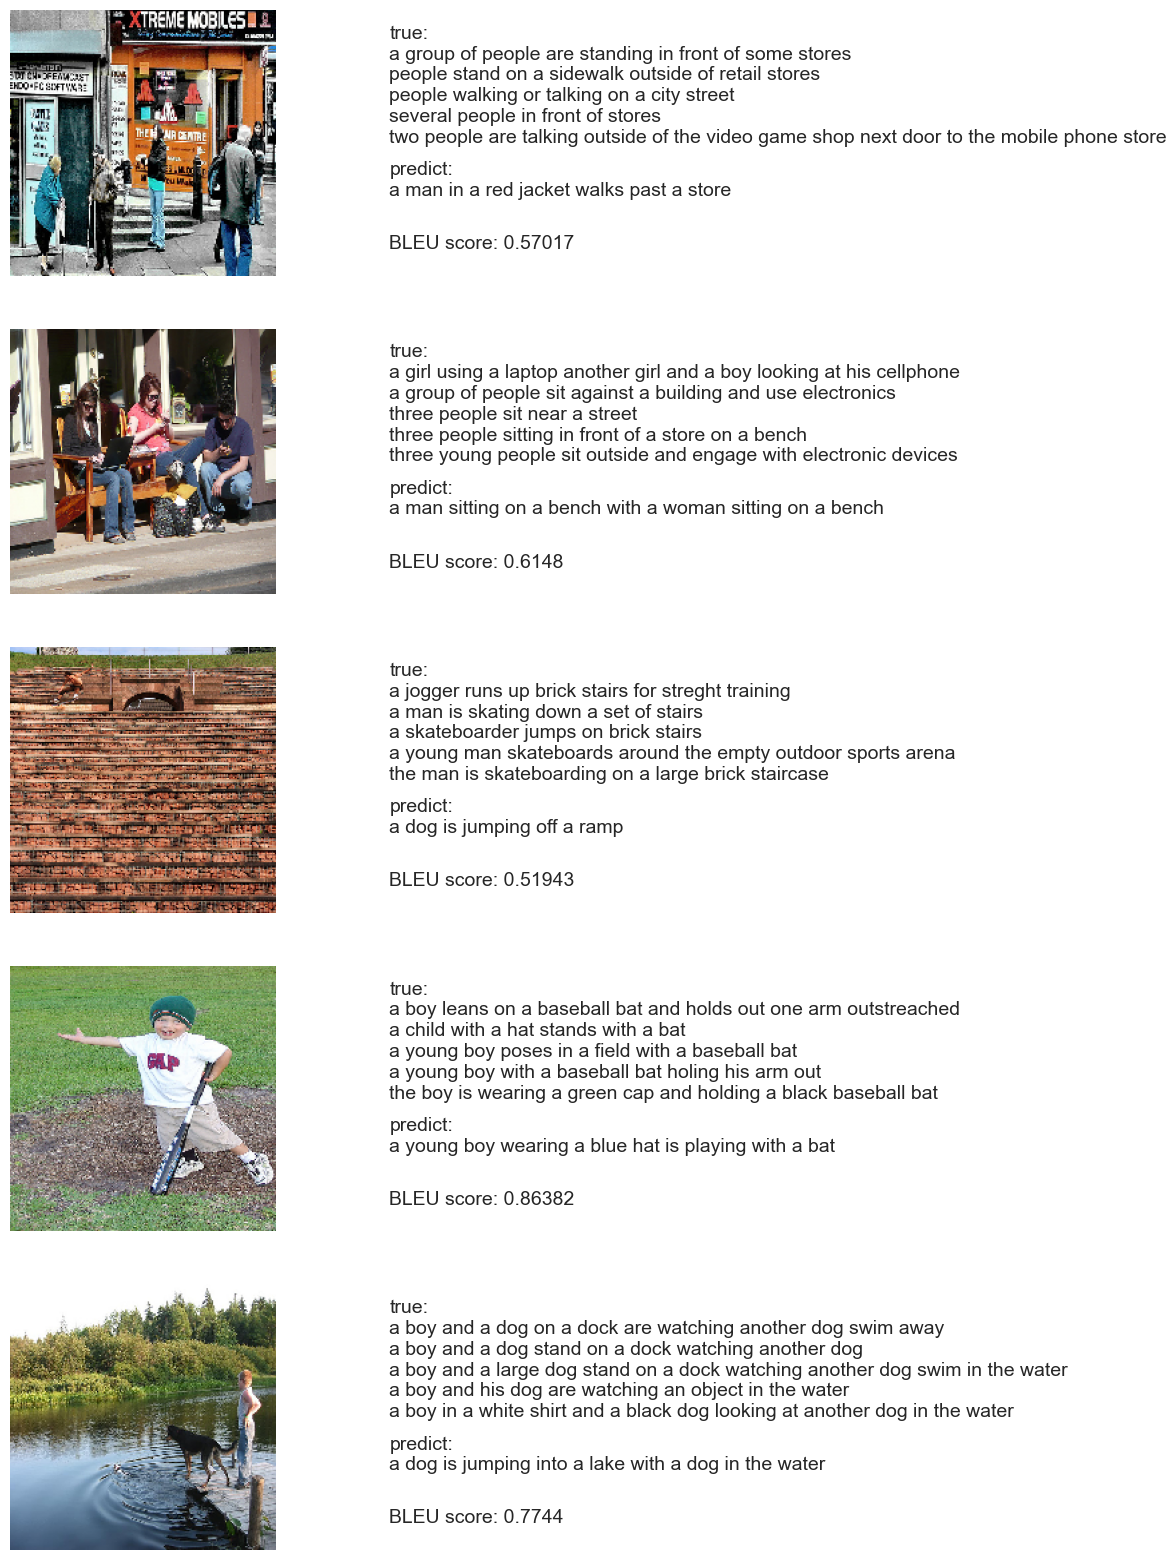

In [147]:
plt.figure(figsize=(10, 20))
for i in range(5):
    image_id = np.random.choice(test_ids)
    plt.subplot(5, 2, 2*i+1)
    plt.axis('off')
    img = load_img(images_dir + image_id, target_size=(199, 199, 3))
    plt.imshow(img)
    
    plt.subplot(5, 2, 2*i+2)
    plt.axis('off')
    cap = greedy_generate(image_features[image_id])
    caption_true = captions[captions['image'] == image_id]['caption'].values
    caption_true = [x.replace("start ", "") for x in caption_true]
    caption_true = [x.replace(" end", "") for x in caption_true]
    score = corpus_bleu([caption_true], [cap], weights=(0.3, 0.3, 0.3, 0))
    
    plt.text(0, 0.5, 'true:\n'+'\n'.join(caption_true), fontsize=14)
    plt.text(0, 0.3, f'predict:\n{cap}', fontsize=14)
    plt.text(0, 0.1, f'BLEU score: {round(score, 5)}', fontsize=14)